In [ ]:
'''
Exercise 1b)
Data Cleaning
'''

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt


In [17]:
df=pd.read_csv("Ex1b.csv")

In [18]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [19]:
df.tail()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence
269,67,1,4,160,286,0,2,108,1,1.5,2,3,3,Presence


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [21]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [22]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


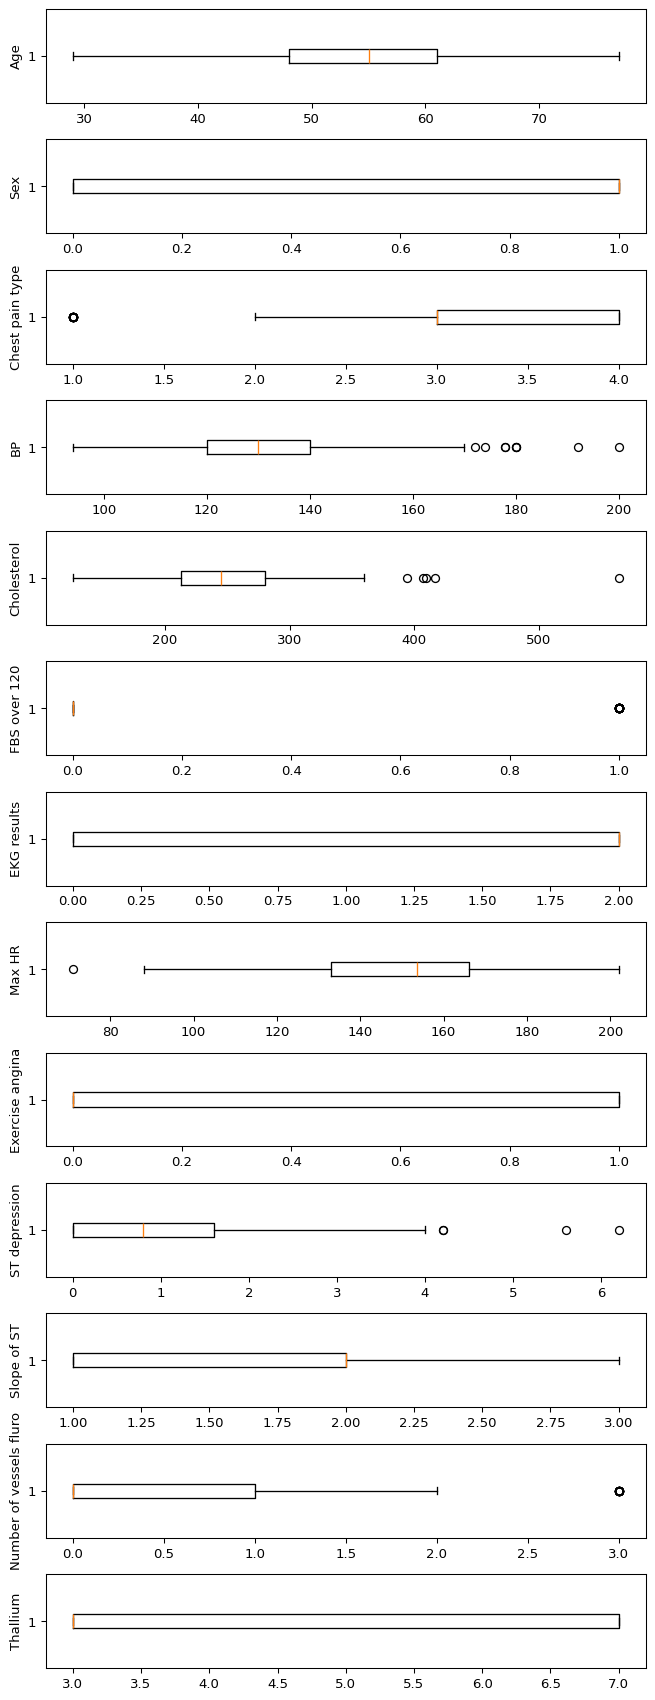

In [23]:
numeric_df = df.select_dtypes(include='number')

fig, axs = plt.subplots(len(numeric_df.columns), 1, figsize=(7, 18), dpi=95)

for i, col in enumerate(numeric_df.columns):
    axs[i].boxplot(numeric_df[col].dropna(), vert=False)
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [24]:
q1, q3 = np.percentile(df["Cholesterol"].dropna(), [25, 75])
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

clean_df = df[(df["Cholesterol"] >= lower) & (df["Cholesterol"] <= upper)
]


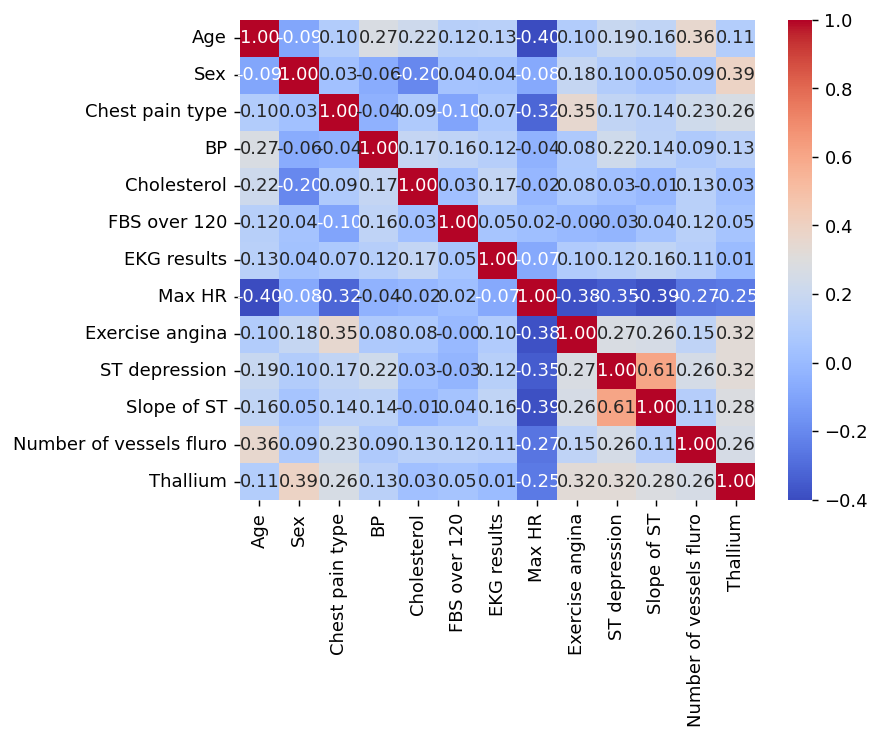

In [25]:
corr = df.select_dtypes(include='number').corr()

plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()


In [26]:
X = df.select_dtypes(include='number')
X_normalized = MinMaxScaler().fit_transform(X)
print(X_normalized[:5])


[[0.85416667 1.         1.         0.33962264 0.44748858 0.
  1.         0.29007634 0.         0.38709677 0.5        1.
  0.        ]
 [0.79166667 0.         0.66666667 0.19811321 1.         0.
  1.         0.67938931 0.         0.25806452 0.5        0.
  1.        ]
 [0.58333333 1.         0.33333333 0.28301887 0.30821918 0.
  0.         0.53435115 0.         0.0483871  0.         0.
  1.        ]
 [0.72916667 1.         1.         0.32075472 0.31278539 0.
  0.         0.25954198 1.         0.03225806 0.5        0.33333333
  1.        ]
 [0.9375     0.         0.33333333 0.24528302 0.32648402 0.
  1.         0.38167939 1.         0.03225806 0.         0.33333333
  0.        ]]


In [27]:
X_standardized = StandardScaler().fit_transform(X)
print(X_standardized[:5])

[[ 1.71209356  0.6894997   0.87092765 -0.07540984  1.40221232 -0.41702883
   0.98166365 -1.75920811 -0.7012223   1.18101235  0.67641928  2.47268219
  -0.87570581]
 [ 1.38213977 -1.45032695 -0.18355874 -0.91675934  6.0930045  -0.41702883
   0.98166365  0.44640927 -0.7012223   0.48115318  0.67641928 -0.71153494
   1.18927733]
 [ 0.2822938   0.6894997  -1.23804513 -0.41194964  0.21982255 -0.41702883
  -1.02628472 -0.37529132 -0.7012223  -0.65611797 -0.95423434 -0.71153494
   1.18927733]
 [ 1.05218598  0.6894997   0.87092765 -0.18758978  0.25858943 -0.41702883
  -1.02628472 -1.93219771  1.4260813  -0.74360037  0.67641928  0.34987077
   1.18927733]
 [ 2.15203195 -1.45032695 -1.23804513 -0.63630951  0.37489006 -0.41702883
   0.98166365 -1.24023932  1.4260813  -0.74360037 -0.95423434  0.34987077
  -0.87570581]]
